In [1]:
# This is a comment - Python ignores it
print("Hello Data Science World!")

# Variables - like boxes that store stuff
my_name = "Harsh Hariya"
my_age = 29
print(f"I'm {my_name} and I'm {my_age} years old")

Hello Data Science World!
I'm Harsh Hariya and I'm 29 years old


In [2]:
# A list of salaries in thousands
salaries = [30, 45, 50, 38, 60, 55, 42]

# Basic operations
print(f"Number of people: {len(salaries)}")
print(f"Highest salary: {max(salaries)}k")
print(f"Lowest salary: {min(salaries)}k")
print(f"Average salary: {sum(salaries)/len(salaries)}k")

Number of people: 7
Highest salary: 60k
Lowest salary: 30k
Average salary: 45.714285714285715k


In [3]:
# Import pandas (Excel on steroids)
import pandas as pd

# Create a simple dataset
data = {
    'Name': ['Rahul', 'Priya', 'Amit', 'Sneha', 'Vikram'],
    'Age': [25, 28, 22, 30, 27],
    'City': ['Mumbai', 'Delhi', 'Bangalore', 'Mumbai', 'Pune'],
    'Salary': [50000, 65000, 48000, 70000, 55000]
}

# Convert to DataFrame (fancy table)
df = pd.DataFrame(data)

# Display it
print(df)

     Name  Age       City  Salary
0   Rahul   25     Mumbai   50000
1   Priya   28      Delhi   65000
2    Amit   22  Bangalore   48000
3   Sneha   30     Mumbai   70000
4  Vikram   27       Pune   55000


In [6]:
# Quick stats
print("=== DATASET OVERVIEW ===")
print(df.info())
print("\n=== STATISTICS ===")
print(df.describe())

# Answer questions
print("\n=== INSIGHTS ===")
print(f"Average salary: ₹{df['Salary'].mean()}")
print(f"Highest paid person: {df.loc[df['Salary'].idxmax(), 'Name']}")
print(f"People in Mumbai: {df[df['City'] == 'Mumbai'].shape[0]}")

=== DATASET OVERVIEW ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   City    5 non-null      object
 3   Salary  5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes
None

=== STATISTICS ===
            Age        Salary
count   5.00000      5.000000
mean   26.40000  57600.000000
std     3.04959   9555.103348
min    22.00000  48000.000000
25%    25.00000  50000.000000
50%    27.00000  55000.000000
75%    28.00000  65000.000000
max    30.00000  70000.000000

=== INSIGHTS ===
Average salary: ₹57600.0
Highest paid person: Sneha
People in Mumbai: 2


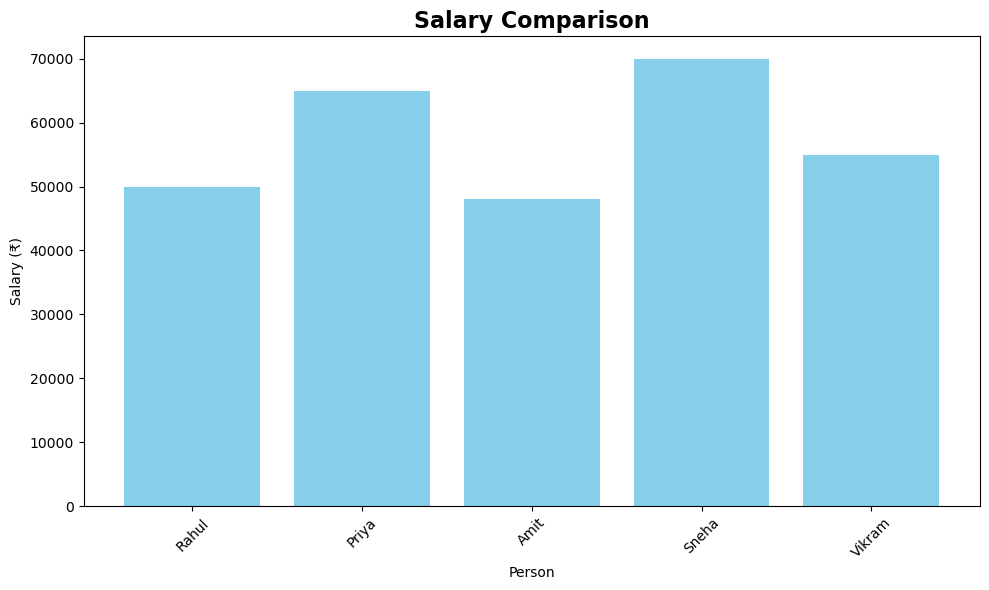

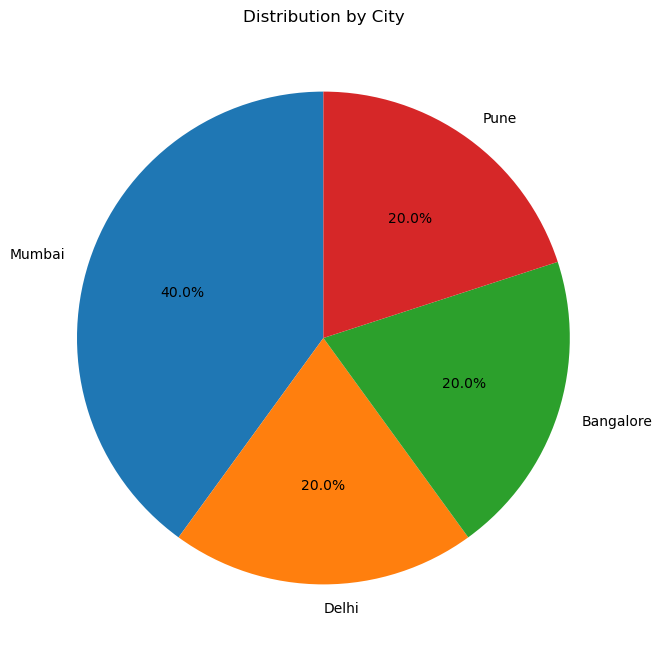

In [7]:
import matplotlib.pyplot as plt

# Bar chart of salaries
plt.figure(figsize=(10, 6))
plt.bar(df['Name'], df['Salary'], color='skyblue')
plt.title('Salary Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Person')
plt.ylabel('Salary (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart of cities
city_counts = df['City'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution by City')
plt.show()

In [9]:
# We'll use a real salary dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Load it
df = pd.read_csv(url)

# See first few rows
print(df.head())
print(f"\nDataset has {len(df)} rows and {len(df.columns)} columns")

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

D

In [10]:
# What columns do we have?
print(df.columns)

# Any missing data?
print("\nMissing values:")
print(df.isnull().sum())

# Basic stats
print("\nStatistics:")
print(df.describe())

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.0000

In [11]:
# Question 1: What was the survival rate?
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Question 2: Did gender matter?
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("\nSurvival rate by gender:")
print(gender_survival)

# Question 3: Did ticket class matter?
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\nSurvival rate by class:")
print(class_survival)

# Question 4: What was the average age?
avg_age = df['Age'].mean()
print(f"\nAverage age of passengers: {avg_age:.1f} years")

Overall survival rate: 38.4%

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average age of passengers: 29.7 years


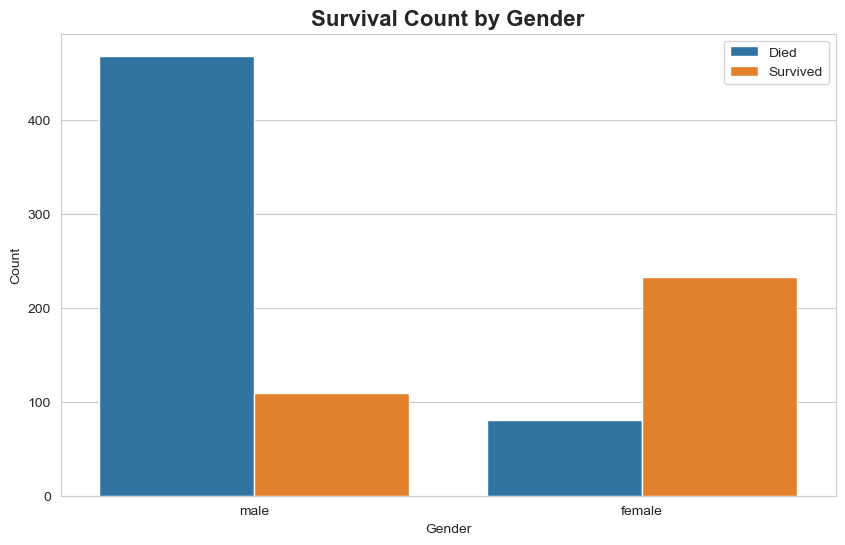

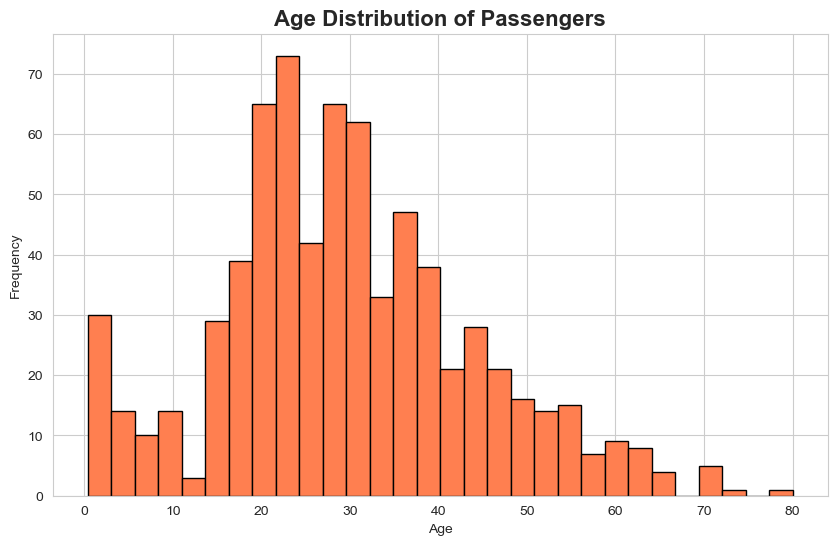

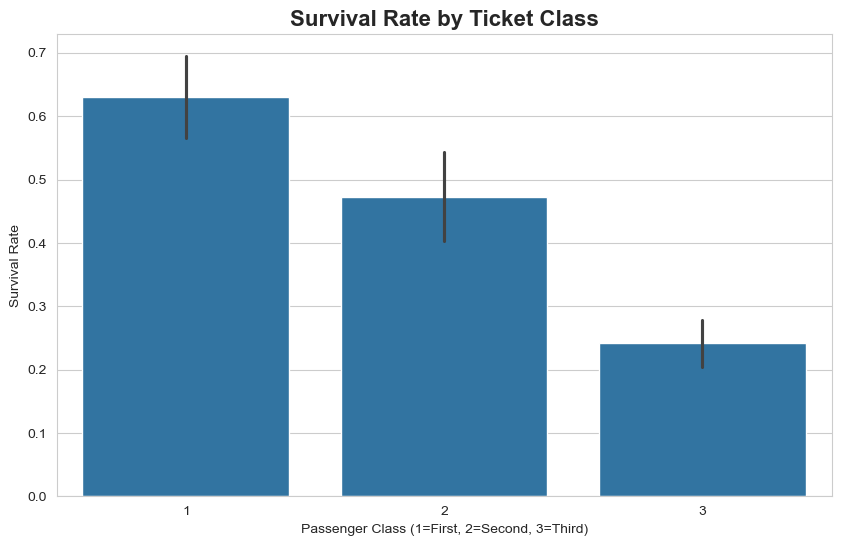

In [12]:
import seaborn as sns

# Set style
sns.set_style('whitegrid')

# 1. Survival by Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.show()

# 2. Age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=30, color='coral', edgecolor='black')
plt.title('Age Distribution of Passengers', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 3. Survival by Class
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Ticket Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.show()

# Titanic Dataset Analysis - Key Findings

## Dataset Overview
- Total passengers: 891
- Survival rate: 38.4%

## Key Insights

### 1. Gender Analysis
- Women had 74.2% survival rate
- Men had 18.9 survival rate
- **Conclusion:** WOmen were saved first, and then Men

### 2. Class Analysis
- First class: 62% survival
- Second class: 47.2% survival  
- Third class: 24.2% survival
- **Conclusion:** FIrst class passenger had good survival rate 

### 3. Age Pattern
- Average age: 29.7 years
- Age group was 20-40, where highest age frequency was 22-24 age group

## What I Learned
[Write 3-4 sentences about what surprised you in this data]